In [7]:
import csv
import matplotlib.pyplot as plt

# Force white background
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

# === CONFIGURATION ===
csv_file = 'relative_uplift_timeseries_06.csv'

# === LOAD DATA ===
times = []
block_names = []
uplift_data = {}

with open(csv_file, 'r') as f:
    reader = csv.reader(f)
    header = next(reader)

    # Header now has: ['Step', 'Time', 'B-1-1', ...]
    block_names = header[2:]   # skip Step and Time columns

    for block in block_names:
        uplift_data[block] = []

    for row in reader:
        time_str = row[1]
        if time_str:
            times.append(float(time_str))
        else:
            times.append(None)

        for i, block in enumerate(block_names):
            val = row[i + 2]
            uplift_data[block].append(float(val) if val else None)

# === COMPUTE MAX UPLIFT AT EACH TIME STEP ===
max_uplift = []
print(max_uplift)

for i in range(len(times)):
    # Gather all uplift values at time index i
    values_at_t = [
        uplift_data[block][i]
        for block in block_names
        if uplift_data[block][i] is not None
    ]

    if values_at_t:
        max_uplift.append(max(values_at_t))
    else:
        max_uplift.append(None)
print(max_uplift)
# === PLOT MAX UPLIFT ===
plt.figure(figsize=(12, 6))
plt.plot(times, max_uplift, color='red', linewidth=2)
plt.xlabel('Time [s]')
plt.ylabel('Maximum Relative Uplift [model units]')
plt.title('Maximum Relative Uplift Over Time (All Blocks)')
plt.grid(True)
plt.tight_layout()
plt.show()

print("First few times:", times[:10])
print("First few max uplift values:", max_uplift[:10])



FileNotFoundError: [Errno 2] No such file or directory: 'relative_uplift_timeseries_06.csv'

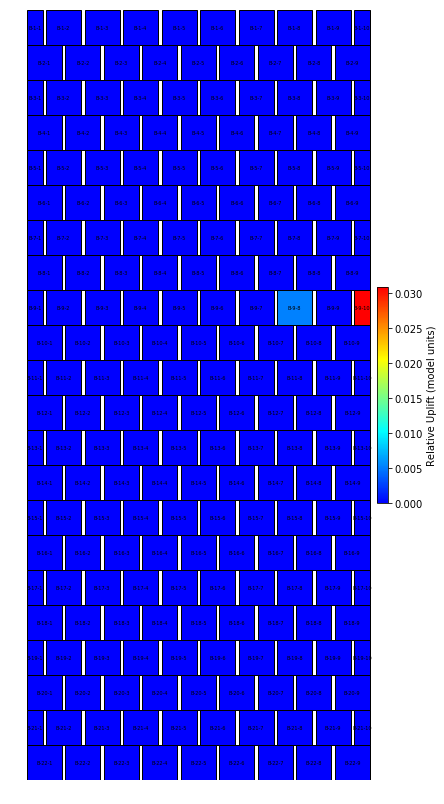

In [11]:
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
import matplotlib.colors as mcolors
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# --- Settings ---
csv_path = 'relative_uplift_timeseries_05.csv'
target_time = 6.03    # time in seconds you want to visualize

# --- Load CSV and get data for time step ---
df = pd.read_csv(csv_path)

# Detect time column automatically
if df.columns[0].lower() == "step":
    time_col = df.columns[1]
else:
    time_col = df.columns[0]

# Round time to 2 decimals for matching
df[time_col] = df[time_col].round(2)
row_df = df[df[time_col] == round(target_time, 2)]

if row_df.empty:
    raise ValueError(f"⛔ Time step {target_time:.2f} not found in CSV.")

# Drop time/step columns to get only block data
block_data = row_df.drop(columns=[df.columns[0], df.columns[1]]).iloc[0]
block_names_all = block_data.index.tolist()

# --- Normalize colors ---
norm = mcolors.Normalize(vmin=np.nanmin(block_data.values),
                         vmax=np.nanmax(block_data.values))

# --- Define custom colormap ---
colors = ["#0000FF", "#00FFFF", "#FFFF00", "#FF0000"]
cmap = LinearSegmentedColormap.from_list("uplift_cmap", colors, N=256)

# Color for blocks with no data
no_data_color = "lightgray"

# --- Block layout settings ---
full_w, full_h = 0.5, 0.5
half_w, half_h = 0.225, 0.5
h_spacing = 0.05
v_spacing = 0.0
rows = 22

# --- Initialize plot ---
fig, ax = plt.subplots(figsize=(6, 12))

# Loop through rows (1 = top, 22 = bottom)
for row_num in range(1, rows + 1):
    current_y = (rows - row_num) * (full_h + v_spacing)
    
    is_half = (row_num % 2 == 1)
    
    if is_half:
        # Odd rows: half + 8 full + half → 10 bricks
        block_sequence = (
            [(half_w, f"B-{row_num}-1")] +
            [(full_w, f"B-{row_num}-{col}") for col in range(2, 10)] +
            [(half_w, f"B-{row_num}-10")]
        )
    else:
        # Even rows: 9 full bricks
        block_sequence = [
            (full_w, f"B-{row_num}-{col}") for col in range(1, 10)
        ]
    
    x = 0.0
    
    for block_w, block_name in block_sequence:
        # Get block value
        if block_name in block_data:
            value = block_data[block_name]
            if np.isnan(value):
                color = no_data_color
            else:
                color = cmap(norm(value))
        else:
            color = no_data_color
        
        # Draw rectangle
        rect = patches.Rectangle(
            (x, current_y),
            block_w, full_h,
            edgecolor='black',
            facecolor=color
        )
        ax.add_patch(rect)
        
        # Draw block name in center
        ax.text(
            x + block_w/2,
            current_y + full_h/2,
            block_name,
            ha='center',
            va='center',
            fontsize=5,
            color='black'
        )
        
        x += block_w + h_spacing

# --- Format figure ---
ax.set_aspect('equal')
ax.set_xlim(0, x)
ax.set_ylim(0, rows * full_h)
ax.axis('off')

# --- Colorbar ---
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.01)
cbar.set_label('Relative Uplift (model units)')

# --- Show figure ---
plt.tight_layout()
plt.show()


✅ Found blocks in first row: ['B-1-1', 'B-1-10', 'B-1-2', 'B-1-3', 'B-1-4', 'B-1-5', 'B-1-6', 'B-1-7', 'B-1-8', 'B-1-9', 'B-10-1', 'B-10-2', 'B-10-3', 'B-10-4', 'B-10-5', 'B-10-6', 'B-10-7', 'B-10-8', 'B-10-9', 'B-11-1', 'B-11-10', 'B-11-2', 'B-11-3', 'B-11-4', 'B-11-5', 'B-11-6', 'B-11-7', 'B-11-8', 'B-11-9', 'B-12-1', 'B-12-2', 'B-12-3', 'B-12-4', 'B-12-5', 'B-12-6', 'B-12-7', 'B-12-8', 'B-12-9', 'B-13-1', 'B-13-10', 'B-13-2', 'B-13-3', 'B-13-4', 'B-13-5', 'B-13-6', 'B-13-7', 'B-13-8', 'B-13-9', 'B-14-1', 'B-14-2', 'B-14-3', 'B-14-4', 'B-14-5', 'B-14-6', 'B-14-7', 'B-14-8', 'B-14-9', 'B-15-1', 'B-15-10', 'B-15-2', 'B-15-3', 'B-15-4', 'B-15-5', 'B-15-6', 'B-15-7', 'B-15-8', 'B-15-9', 'B-16-1', 'B-16-2', 'B-16-3', 'B-16-4', 'B-16-5', 'B-16-6', 'B-16-7', 'B-16-8', 'B-16-9', 'B-17-1', 'B-17-10', 'B-17-2', 'B-17-3', 'B-17-4', 'B-17-5', 'B-17-6', 'B-17-7', 'B-17-8', 'B-17-9', 'B-18-1', 'B-18-2', 'B-18-3', 'B-18-4', 'B-18-5', 'B-18-6', 'B-18-7', 'B-18-8', 'B-18-9', 'B-19-1', 'B-19-10', 'B-1

ValueError: bottom cannot be >= top

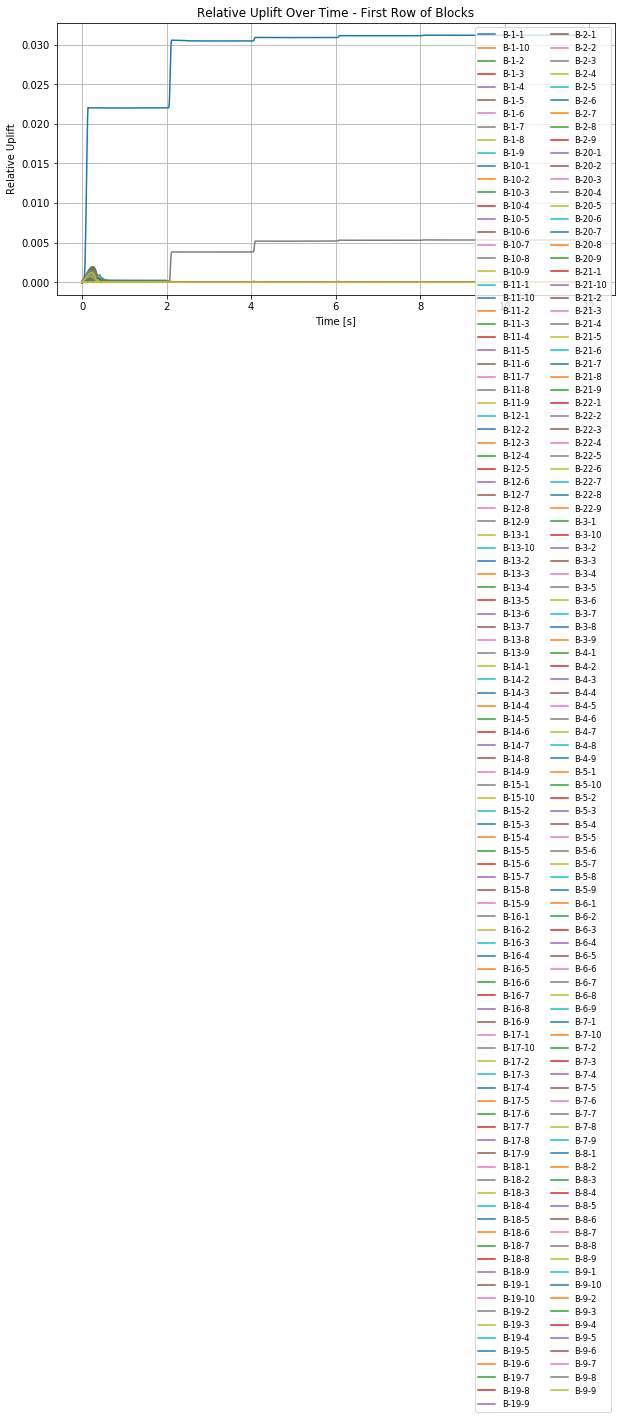

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Settings ---
csv_path = 'relative_uplift_timeseries_05.csv'

# --- Load CSV ---
df = pd.read_csv(csv_path)

# Detect time column automatically
if df.columns[0].lower() == "step":
    time_col = df.columns[1]
else:
    time_col = df.columns[0]

# Extract time array
time_values = df[time_col]

# Find block columns for first row (B-1-…)
block_cols = [col for col in df.columns if col.startswith('B-')]

print(f"✅ Found blocks in first row: {block_cols}")

# Plot
plt.figure(figsize=(10,5))

for col in block_cols:
    plt.plot(time_values, df[col], label=col, linewidth=1.5)

plt.xlabel("Time [s]")
plt.ylabel("Relative Uplift")
plt.title("Relative Uplift Over Time - First Row of Blocks")
plt.legend(loc='upper right', fontsize='small', ncol=2)
plt.grid(True)
plt.tight_layout()
plt.show()


Grid width: 4.900 m
MWL (along slope): 14.10 m
✅ Time 10.50 s belongs to Wave 5 in 1000, H=1.15


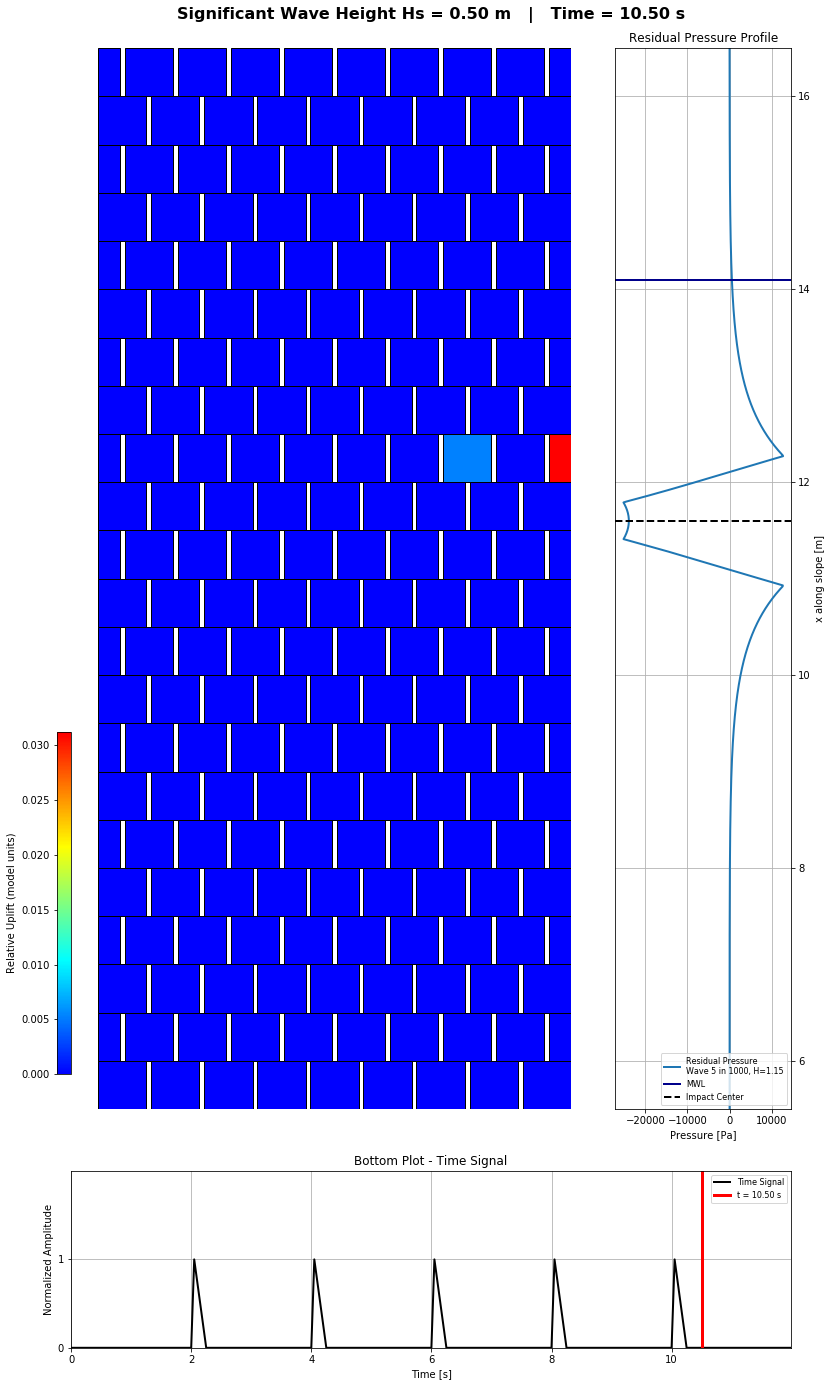

✅ Finished plotting block grid with uplift and residual pressure.


In [77]:
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from scipy.linalg import solve
from mpl_toolkits.axes_grid1 import make_axes_locatable

target_time = 10.5    # time in seconds to visualize

# ------------------------------
# Define brick layout parameters
# ------------------------------
full_w = 0.5
full_h = 0.5
half_w = 0.225
half_h = 0.5
horizontal_spacing = 0.05
v_spacing = 0.0

# Compute grid width for even rows (widest rows)
grid_width = (9 * full_w) + (8 * horizontal_spacing)
print(f"Grid width: {grid_width:.3f} m")

rows = 22

# ------------------------------
# Load uplift data
# ------------------------------

csv_path = 'relative_uplift_timeseries_05.csv'


df_uplift = pd.read_csv(csv_path)

# Detect time column automatically
if df_uplift.columns[0].lower() == "step":
    time_col = df_uplift.columns[1]
else:
    time_col = df_uplift.columns[0]

# Round times for matching
df_uplift[time_col] = df_uplift[time_col].round(2)
row_df = df_uplift[df_uplift[time_col] == round(target_time, 2)]

if row_df.empty:
    raise ValueError(f"⛔ Time step {target_time:.2f} not found in CSV.")

# Drop time columns to get only block data
block_data = row_df.drop(columns=[df_uplift.columns[0], df_uplift.columns[1]]).iloc[0]
block_names_all = block_data.index.tolist()

# Normalize colormap
norm = plt.Normalize(vmin=np.nanmin(block_data.values),
                     vmax=np.nanmax(block_data.values))

# Custom colormap: blue → red
colors = ["#0000FF", "#00FFFF", "#FFFF00", "#FF0000"]
# colors = ["#0000FF", "#FFCC00", "#FF0000"]
# colors = ["#0000FF", "#00BBFF", "#FFFFFF"]
cmap = LinearSegmentedColormap.from_list("uplift_cmap", colors, N=256)

# Color for blocks with no data
no_data_color = "lightgray"

# ------------------------------
# Create time signal for bottom plot
# ------------------------------

# Pulse signal
pulse_t = np.array([0.0, 0.05, 0.25])
pulse_val = np.array([0.0, 1.0, 0.0])

total_waves = 5
pulse_duration = 0.25
pulse_interval = 2.0
gravity_time = 2.0
dt = 0.01

end_time = gravity_time + total_waves * pulse_interval
time_signal = np.arange(0, end_time, dt)

signal = np.zeros_like(time_signal)

for wave in range(total_waves):
    t_start = gravity_time + wave * pulse_interval
    active = (time_signal >= t_start) & (time_signal <= t_start + pulse_duration)
    local_time = time_signal[active] - t_start
    pulse = np.interp(local_time, pulse_t, pulse_val)
    signal[active] = pulse

df_signal = pd.DataFrame({
    "Time": time_signal,
    "Signal": signal
})

# ------------------------------
# Simulate residual profiles
# ------------------------------

# Wave simulation setup
Hs = 0.5
rho_w = 1025.0
g = 9.81
Tp = 5.59
tan_beta = 1.0 / 3.0
D = 0.30
b = 0.30
k = 0.19
k_prime = 0.05
Lambda = np.sqrt(D * b * k / k_prime)
SWL = 4.7
dx = 0.01
x = np.arange(0, 20.0 + dx, dx)
N = len(x)

# MWL x-position along slope
x_mwl = SWL / tan_beta
print(f"MWL (along slope): {x_mwl:.2f} m")

block_length = 0.5
slope = tan_beta
block_dx = block_length * np.cos(np.arctan(slope))
block_start = 6.0
block_positions = [block_start + i * block_dx for i in range(22)]

sigma = Hs / np.sqrt(2)
exceed_probs = np.arange(1, 6, 1) / 1000.0
wave_heights = sigma * np.sqrt(-2 * np.log(exceed_probs))

wave_pressures = {}
residual_profiles = {}
impact_centers = {}

for i, H_wave in enumerate(wave_heights):
    Tm_1_0 = Tp / 1.1
    L_m_1_0 = (g * Tm_1_0 ** 2) / (2.0 * np.pi)
    xi = tan_beta / np.sqrt(H_wave / L_m_1_0)
    z_SWL = H_wave * (0.8 + 0.6 * np.tanh(xi - 2.1)) if xi < 3 else np.nan
    x_center = (SWL - z_SWL) / tan_beta

    w_base = (7 / 6) * H_wave
    w_top = (1 / 3) * H_wave
    x_left_base = x_center - w_base / 2
    x_right_base = x_center + w_base / 2
    x_left_top = x_center - w_top / 2
    x_right_top = x_center + w_top / 2

    denom = (xi - 0.2) ** 2
    P_dimless = 8.0 - 1.6 * xi - 2.0 / denom
    P_max = P_dimless * rho_w * g * H_wave

    p_vals = np.zeros_like(x)
    for j, xx in enumerate(x):
        if x_left_base <= xx < x_left_top:
            p_vals[j] = P_max * (xx - x_left_base) / (x_left_top - x_left_base)
        elif x_left_top <= xx <= x_right_top:
            p_vals[j] = P_max
        elif x_right_top < xx <= x_right_base:
            p_vals[j] = P_max * (x_right_base - xx) / (x_right_base - x_right_top)

    b_vec = -p_vals.copy()
    b_vec[0] = b_vec[-1] = 0
    A = np.zeros((N, N))
    coeff = Lambda ** 2 / dx ** 2
    for j in range(1, N - 1):
        A[j, j - 1] = coeff
        A[j, j] = -2 * coeff - 1
        A[j, j + 1] = coeff
    A[0, 0] = A[-1, -1] = 1.0
    phi_F = solve(A, b_vec)
    residual = phi_F - p_vals

    wave_name = f"Wave {i+1} in 1000, H={H_wave:.2f}"
    residual_profiles[wave_name] = residual
    wave_pressures[wave_name] = p_vals
    impact_centers[wave_name] = x_center

# Pick a default wave in case no wave is active
wave_to_plot = list(residual_profiles.keys())[0]

# ------------------------------
# Determine active wave
# ------------------------------

active_wave = None

for wave_idx in range(total_waves):
    t_start = gravity_time + wave_idx * pulse_interval
    t_end = gravity_time + (wave_idx + 1) * pulse_interval

    if t_start <= target_time < t_end:
        active_wave = wave_idx
        break

if active_wave is not None:
    wave_name = list(residual_profiles.keys())[active_wave]
    print(f"✅ Time {target_time:.2f} s belongs to {wave_name}")
else:
    print(f"ℹ️ Time {target_time:.2f} s is during gravity loading or after waves.")

# ------------------------------
# Create figure with subplots
# ------------------------------

fig = plt.figure(figsize=(10, 19))

gs = gridspec.GridSpec(
    nrows=2,
    ncols=2,
    width_ratios=[3, 1],
    height_ratios=[6, 1],
    wspace=0.05,
    hspace=0.1
)

# === TOP LEFT AXES (block grid with uplift data) ===
ax_grid = fig.add_subplot(gs[0, 0])

for row_num in range(1, rows + 1):
    current_y = (rows - row_num) * (full_h + v_spacing)
    
    is_half = (row_num % 2 == 1)
    
    if is_half:
        block_sequence = (
            [(half_w, f"B-{row_num}-1")] +
            [(full_w, f"B-{row_num}-{col}") for col in range(2, 10)] +
            [(half_w, f"B-{row_num}-10")]
        )
    else:
        block_sequence = [
            (full_w, f"B-{row_num}-{col}") for col in range(1, 10)
        ]
    
    x_pos = 0.0
    
    for block_w, block_name in block_sequence:
        if block_name in block_data:
            value = block_data[block_name]
            if np.isnan(value):
                color = no_data_color
            else:
                color = cmap(norm(value))
        else:
            color = no_data_color
        
        rect = patches.Rectangle(
            (x_pos, current_y),
            block_w, full_h,
            edgecolor='black',
            facecolor=color,
            linewidth=1
        )
        ax_grid.add_patch(rect)
        
        x_pos += block_w + horizontal_spacing

ax_grid.set_aspect('equal')
ax_grid.set_xlim(0, grid_width)
ax_grid.set_ylim(0, rows * full_h)
ax_grid.axis('off')

# Add colorbar on the left side
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cax = fig.add_axes([-0.02, 0.2, 0.02, 0.25])
cbar = plt.colorbar(sm, cax=cax, orientation='vertical')
cbar.set_label('Relative Uplift (model units)')
cbar.ax.yaxis.set_label_position('left')
cbar.ax.yaxis.set_ticks_position('left')

# === TOP RIGHT AXES (residual profile of active wave only) ===
ax_side = fig.add_subplot(gs[0, 1])

if active_wave is not None:
    wave_name = list(residual_profiles.keys())[active_wave]
    residual_vals = residual_profiles[wave_name]
    x_center = impact_centers[wave_name]
else:
    wave_name = wave_to_plot
    residual_vals = residual_profiles[wave_name]
    x_center = impact_centers[wave_name]

ax_side.plot(
    residual_vals,
    x,
    color='#1f77b4',
    linewidth=2,
    label=f"Residual Pressure\n{wave_name}"
)

# Plot MWL
ax_side.axhline(
    x_mwl,
    color='darkblue',
    linestyle='-',
    linewidth=2,
    label='MWL'
)

# Plot Impact Center
ax_side.axhline(
    x_center,
    color='black',
    linestyle='--',
    linewidth=2,
    label='Impact Center'
)

ax_side.invert_yaxis()
ax_side.set_xlabel('Pressure [Pa]')
ax_side.set_ylabel('x along slope [m]')
ax_side.set_ylim(5.5, 16.5)
ax_side.yaxis.tick_right()
ax_side.yaxis.set_label_position("right")
ax_side.set_title("Residual Pressure Profile")
ax_side.grid(True)
ax_side.legend(loc='lower right', fontsize=8)

# === BOTTOM AXES (time signal) ===
ax_bottom = fig.add_subplot(gs[1, :])

ax_bottom.plot(
    df_signal["Time"],
    df_signal["Signal"],
    color='black',
    linewidth=2,
    label='Time Signal'
)

# Add vertical line at target_time
ax_bottom.axvline(
    target_time,
    color='red',
    linestyle='-',
    linewidth=3,
    label=f"t = {target_time:.2f} s"
)

ax_bottom.set_xlim(0, df_signal["Time"].iloc[-1])
ax_bottom.set_xlabel('Time [s]')
ax_bottom.set_ylabel('Normalized Amplitude')
ax_bottom.set_yticks([0, 1])
ax_bottom.set_ylim(0, 2)
ax_bottom.grid(True)
ax_bottom.set_title('Bottom Plot - Time Signal')
ax_bottom.legend(loc='upper right', fontsize=8)

# Add figure title
fig.suptitle(
    f"Significant Wave Height Hs = {Hs:.2f} m   |   Time = {target_time:.2f} s",
    fontsize=16,
    fontweight="bold"
)

plt.subplots_adjust(left=0, right=1, top=0.95, bottom=0, wspace=0, hspace=0)

plt.show()

print("✅ Finished plotting block grid with uplift and residual pressure.")


In [1]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import os

# ------------------------------
# CONFIGURATION
# ------------------------------

runs = ["06_DS60_2"]

file_pattern = "relative_uplift_timeseries_{}.csv"
depth_limit = 0.15         # meters
fly_out_value = 0.151       # value to assign once a block flies out
half_block_value = 0.0     # value to assign to half blocks (odd columns)

output_suffix = "_corrected.csv"

# ------------------------------
# CORRECT CSVs
# ------------------------------

for run in runs:
    csv_path = file_pattern.format(run)
    corrected_path = csv_path.replace(".csv", output_suffix)

    print(f"\n=== Correcting {csv_path} ===")

    # Load CSV
    df = pd.read_csv(csv_path)

    # Detect time columns automatically
    if df.columns[0].lower() == "step":
        time_cols = list(df.columns[:2])
        data_cols = list(df.columns[2:])
    else:
        time_cols = list(df.columns[:1])
        data_cols = list(df.columns[1:])

    # --------------------------------------------------
    # Calculate cumulative time if Step and StepTime exist
    # --------------------------------------------------

    if df.columns[0].lower() == "step":
        step_col = df.columns[0]
        step_time_col = df.columns[1]

        df[step_time_col] = pd.to_numeric(df[step_time_col], errors="coerce")

        cumulative_time = []
        time_offset = 0.0

        for step_name, group in df.groupby(step_col, sort=False):
            times = group[step_time_col]
            cumulative_times = times + time_offset
            cumulative_time.extend(cumulative_times)
            time_offset = cumulative_times.iloc[-1]

        df["CumulativeTime"] = cumulative_time

    # --------------------------------------------------
    # Check and correct uplift data
    # --------------------------------------------------

    data_values = df[data_cols].values.copy()

    # Boolean mask: True → block has flown out
    has_flown_out = np.zeros(len(data_cols), dtype=bool)

    for i in range(data_values.shape[0]):
        for j in range(data_values.shape[1]):
            if has_flown_out[j]:
                data_values[i, j] = fly_out_value
            else:
                val = data_values[i, j]
                if not np.isnan(val) and val > depth_limit:
                    has_flown_out[j] = True
                    data_values[i, j] = fly_out_value

    # --------------------------------------------------
    # Replace half blocks (odd-numbered columns)
    # --------------------------------------------------

    # Note: enumerate starting from 1 because user considers col 1, 3, 5 etc. as odd
    for idx, col in enumerate(data_cols, start=1):
        if idx % 2 == 1:
            # Overwrite entire column for half blocks
            data_values[:, idx - 1] = half_block_value

    # Create corrected DataFrame
    corrected_parts = [df[time_cols]]

    if "CumulativeTime" in df.columns:
        corrected_parts.append(df[["CumulativeTime"]])

    corrected_parts.append(pd.DataFrame(data_values, columns=data_cols))

    df_corrected = pd.concat(corrected_parts, axis=1)

    # Save corrected file
    df_corrected.to_csv(corrected_path, index=False)
    print(f"✅ Saved corrected file: {corrected_path}")



=== Correcting relative_uplift_timeseries_06_DS60_2.csv ===
✅ Saved corrected file: relative_uplift_timeseries_06_DS60_2_corrected.csv


In [3]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import os

# ------------------------------
# CONFIGURATION
# ------------------------------

runs = ["06_DS60_2"]

orig_file_pattern = "relative_uplift_timeseries_{}.csv"
corr_file_pattern = "relative_uplift_timeseries_{}_corrected.csv"

target_time = 11   # time in seconds
D = 0.15             # block diameter in meters
# fly_out_value = 2.01

# Define damage category thresholds
damage_thresholds = [
    (0.01, 0.33, 1),
    (0.33, 0.67, 2),
    (0.67, 1.0, 3),
    (1.0, float('inf'), 4)
]

# ------------------------------
# ANALYZE ALL RUNS
# ------------------------------

for run in runs:
    print(f"\n\n============================")
    print(f"RUN {run}")
    print(f"============================")

    for label, file_pattern in [("Original", orig_file_pattern),
                                ("Corrected", corr_file_pattern)]:

        csv_path = file_pattern.format(run)

        # Check if file exists
        if not os.path.exists(csv_path):
            print(f"⛔ {label} CSV file not found: {csv_path}")
            continue

        # Load CSV
        df_uplift = pd.read_csv(csv_path)

        # Detect time column automatically
        if df_uplift.columns[0].lower() == "step":
            time_col = "CumulativeTime" if "CumulativeTime" in df_uplift.columns else df_uplift.columns[1]
        else:
            time_col = df_uplift.columns[0]

        # Round time for matching
        df_uplift[time_col] = df_uplift[time_col].round(2)

        # Find the row at the desired time
        row_df = df_uplift[df_uplift[time_col] == round(target_time, 2)]

        if row_df.empty:
            print(f"⛔ {label} CSV: Time step {target_time:.2f} s not found in {csv_path}. Skipping.")
            continue

        # Extract only block columns (those starting with "B-")
        block_cols = [c for c in row_df.columns if c.startswith("B-")]

        if not block_cols:
            print(f"⛔ {label} CSV: No block columns found in {csv_path}. Skipping.")
            continue

        block_data = row_df[block_cols].iloc[0]

        # KEEP fly-out values so they count as damage
        uplift_values = block_data.values
        ze_over_D = uplift_values / D

        # Count damage categories
        damage_counts = {cat: 0 for _, _, cat in damage_thresholds}

        for val_norm in ze_over_D:
            if np.isnan(val_norm) or val_norm <= 0:
                continue
            for lower, upper, cat in damage_thresholds:
                if lower < val_norm <= upper:
                    damage_counts[cat] += 1
                    break

        # Print damage summary
        print(f"\n✅ {label} CSV - Damage summary at t = {target_time:.2f} s:")
        for cat in [1, 2, 3, 4]:
            print(f"Damage category {cat}: {damage_counts[cat]} blocks")




RUN 06_DS60_2

✅ Original CSV - Damage summary at t = 11.00 s:
Damage category 1: 53 blocks
Damage category 2: 0 blocks
Damage category 3: 0 blocks
Damage category 4: 0 blocks

✅ Corrected CSV - Damage summary at t = 11.00 s:
Damage category 1: 26 blocks
Damage category 2: 0 blocks
Damage category 3: 0 blocks
Damage category 4: 0 blocks


In [4]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ------------------------------
# CONFIGURATION
# ------------------------------

runs = ["06_DS60_2"]
file_pattern = "relative_uplift_timeseries_{}_corrected.csv"

# fly_out_value = 2.01
target_time = 10.5
D = 0.15  # block diameter [m]

# Define damage category thresholds
damage_thresholds = [
    (0.0, 0.33, 1),
    (0.33, 0.67, 2),
    (0.67, 1.0, 3),
    (1.0, float('inf'), 4)
]

results_table = {
    "Run": [],
    "Damage Cat 1": [],
    "Damage Cat 2": [],
    "Damage Cat 3": [],
    "Damage Cat 4": []
}

# ------------------------------
# ANALYZE DAMAGE
# ------------------------------

for run in runs:
    csv_path = file_pattern.format(run)

    print(f"\n=== Analyzing {csv_path} ===")

    if not os.path.exists(csv_path):
        print(f"⛔ File not found: {csv_path}. Skipping.")
        continue

    df_uplift = pd.read_csv(csv_path)

    # Detect time column automatically
    if df_uplift.columns[0].lower() == "step":
        time_col = "CumulativeTime" if "CumulativeTime" in df_uplift.columns else df_uplift.columns[1]
    else:
        time_col = df_uplift.columns[0]

    # Round time for matching
    df_uplift[time_col] = df_uplift[time_col].round(2)

    # Find the row at the desired time
    row_df = df_uplift[df_uplift[time_col] == round(target_time, 2)]

    if row_df.empty:
        print(f"⛔ Time step {target_time:.2f} s not found in {csv_path}. Skipping.")
        continue

    # Extract only block columns (those starting with "B-")
    block_cols = [c for c in row_df.columns if c.startswith("B-")]

    if not block_cols:
        print(f"⛔ No block columns found in {csv_path}. Skipping.")
        continue

    block_data = row_df[block_cols].iloc[0]

    # Keep fly-out values numeric so they fall in the highest category
    uplift_values = block_data.values
    ze_over_D = uplift_values / D

    # Initialize counters
    damage_counts = {cat: 0 for _, _, cat in damage_thresholds}

    for val_norm in ze_over_D:
        if np.isnan(val_norm) or val_norm <= 0:
            continue
        for lower, upper, cat in damage_thresholds:
            if lower < val_norm <= upper:
                damage_counts[cat] += 1
                break

    results_table["Run"].append(run)
    results_table["Damage Cat 1"].append(damage_counts[1])
    results_table["Damage Cat 2"].append(damage_counts[2])
    results_table["Damage Cat 3"].append(damage_counts[3])
    results_table["Damage Cat 4"].append(damage_counts[4])

    print(f"\n✅ Damage category summary at t = {target_time:.2f} s for run {run}:")
    for cat in [1, 2, 3, 4]:
        print(f"Damage category {cat}: {damage_counts[cat]} blocks")

# ------------------------------
# PRINT RESULTS
# ------------------------------

df_results = pd.DataFrame(results_table)

if not df_results.empty:
    print("\n✅ Summary Table (Damage Categories)\n")
    print(df_results.to_string(index=False))
else:
    print("No data to display.")

# ------------------------------
# PLOT RESULTS
# ------------------------------

if not df_results.empty:
    fig, ax = plt.subplots(figsize=(8, 5))

    categories = ["Damage Cat 1", "Damage Cat 2", "Damage Cat 3", "Damage Cat 4"]
    indices = np.arange(len(categories))
    bar_width = 0.2

    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

    for i, run in enumerate(df_results["Run"]):
        values = df_results.loc[df_results["Run"] == run, categories].values[0]
        ax.bar(
            indices + i * bar_width,
            values,
            width=bar_width,
            label=f"Run {run}",
            color=colors[i % len(colors)]
        )

    ax.set_xlabel("Damage Category")
    ax.set_ylabel("Number of Blocks")
    ax.set_title(f"Damage Categories at t = {target_time:.2f} s")
    ax.set_xticks(indices + bar_width * (len(runs)-1)/2)
    ax.set_xticklabels(["Cat 1", "Cat 2", "Cat 3", "Cat 4"])
    ax.legend(title="Run")

    plt.tight_layout()
    plt.show()
else:
    print("No data to plot.")



=== Analyzing relative_uplift_timeseries_06_DS60_2_corrected.csv ===

✅ Damage category summary at t = 10.50 s for run 06_DS60_2:
Damage category 1: 29 blocks
Damage category 2: 0 blocks
Damage category 3: 0 blocks
Damage category 4: 0 blocks

✅ Summary Table (Damage Categories)

Run  Damage Cat 1  Damage Cat 2  Damage Cat 3  Damage Cat 4
06_DS60_2            29             0             0             0


<Figure size 800x500 with 1 Axes>


=== Processing relative_uplift_timeseries_06_DS60_2_corrected.csv ===

✅ Damage category summary at t = 10.50 s for run 06_DS60_2:
Damage category A: 26 blocks
Damage category B: 0 blocks
Damage category C: 0 blocks
Damage category D: 0 blocks

✅ Summary Table (Damage Categories)

Run  Damage Cat A  Damage Cat B  Damage Cat C  Damage Cat D
06_DS60_2            26             0             0             0


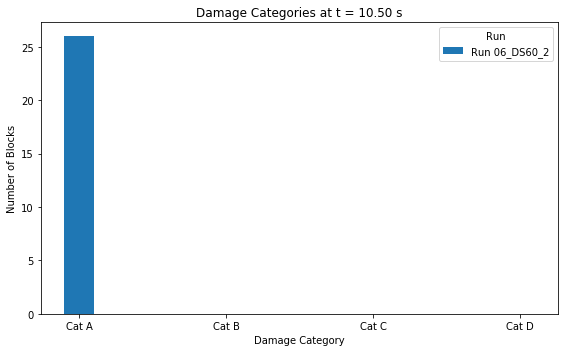

In [8]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ------------------------------
# CONFIGURATION
# ------------------------------

runs = ["06_DS60_2"]

file_pattern = "relative_uplift_timeseries_{}_corrected.csv"

# fly_out_value = 2.01
target_time = 10.5
D = 0.15  # block diameter [m]

# Define damage category thresholds
damage_thresholds = [
    (0.01, 0.1, "A"),
    (0.1, 0.2, "B"),
    (0.2, 0.5, "C"),
    (0.5, float("inf"), "D"),
]

# Results storage
results_table = {
    "Run": [],
    "Damage Cat A": [],
    "Damage Cat B": [],
    "Damage Cat C": [],
    "Damage Cat D": []
}

# ------------------------------
# ANALYZE CORRECTED CSVs
# ------------------------------

for run in runs:
    corrected_path = file_pattern.format(run)

    print(f"\n=== Processing {corrected_path} ===")

    if not os.path.exists(corrected_path):
        print(f"⛔ File not found: {corrected_path}. Skipping.")
        continue

    # Load corrected CSV
    df_uplift = pd.read_csv(corrected_path)

    # Detect time column automatically
    if df_uplift.columns[0].lower() == "step":
        time_col = (
            "CumulativeTime"
            if "CumulativeTime" in df_uplift.columns
            else df_uplift.columns[1]
        )
    else:
        time_col = df_uplift.columns[0]

    # Round time for matching
    df_uplift[time_col] = df_uplift[time_col].round(2)

    row_df = df_uplift[df_uplift[time_col] == round(target_time, 2)]

    if row_df.empty:
        print(f"⛔ Time step {target_time:.2f} s not found in {corrected_path}. Skipping.")
        continue

    # Extract only block columns (those starting with "B-")
    block_cols = [c for c in row_df.columns if c.startswith("B-")]

    if not block_cols:
        print(f"⛔ No block columns found in {corrected_path}. Skipping.")
        continue

    block_data = row_df[block_cols].iloc[0]

    # Keep fly-out values numeric so they fall into category D
    uplift_values = block_data.values
    ze_over_D = uplift_values / D

    # Initialize counters
    damage_counts = {cat: 0 for _, _, cat in damage_thresholds}

    for val_norm in ze_over_D:
        if np.isnan(val_norm) or val_norm <= 0:
            continue

        for lower, upper, cat in damage_thresholds:
            if lower < val_norm <= upper:
                damage_counts[cat] += 1
                break

    results_table["Run"].append(run)
    results_table["Damage Cat A"].append(damage_counts["A"])
    results_table["Damage Cat B"].append(damage_counts["B"])
    results_table["Damage Cat C"].append(damage_counts["C"])
    results_table["Damage Cat D"].append(damage_counts["D"])

    print(f"\n✅ Damage category summary at t = {target_time:.2f} s for run {run}:")
    for cat in ["A", "B", "C", "D"]:
        print(f"Damage category {cat}: {damage_counts[cat]} blocks")

# ------------------------------
# PRINT TABLE
# ------------------------------

df_results = pd.DataFrame(results_table)

if not df_results.empty:
    print("\n✅ Summary Table (Damage Categories)\n")
    print(df_results.to_string(index=False))
else:
    print("No data to display.")

# ------------------------------
# PLOT RESULTS
# ------------------------------

if not df_results.empty:
    fig, ax = plt.subplots(figsize=(8, 5))

    categories = ["Damage Cat A", "Damage Cat B", "Damage Cat C", "Damage Cat D"]
    indices = np.arange(len(categories))
    bar_width = 0.2

    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    
    for i, run in enumerate(df_results["Run"]):
        values = df_results.loc[df_results["Run"] == run, categories].values[0]
        ax.bar(
            indices + i * bar_width,
            values,
            width=bar_width,
            label=f"Run {run}",
            color=colors[i % len(colors)]
        )

    ax.set_xlabel("Damage Category")
    ax.set_ylabel("Number of Blocks")
    ax.set_title(f"Damage Categories at t = {target_time:.2f} s")
    ax.set_xticks(indices + bar_width * (len(runs)-1)/2)
    ax.set_xticklabels(["Cat A", "Cat B", "Cat C", "Cat D"])
    ax.legend(title="Run")

    plt.tight_layout()
    plt.show()
else:
    print("No data to plot.")


✅ Found 209 block columns.


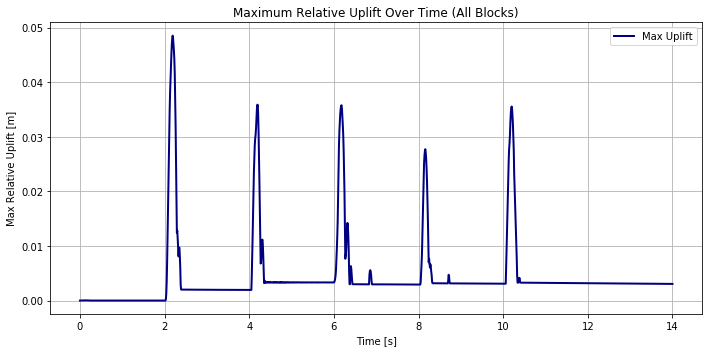

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Settings ---
runs = ["06_DS60_2"]
csv_path = 'relative_uplift_timeseries_06_DS60_2_corrected.csv'
fly_out_value = 0.151

# --- Load CSV ---
df = pd.read_csv(csv_path)

# Detect time column automatically
if "CumulativeTime" in df.columns:
    time_col = "CumulativeTime"
elif df.columns[0].lower() == "step":
    time_col = df.columns[1]
else:
    time_col = df.columns[0]

# Extract time array
time_values = df[time_col]

# Find all block columns (assuming they start with 'B-')
block_cols = [col for col in df.columns if col.startswith('B-')]

if not block_cols:
    print("⛔ No block columns found!")
else:
    print(f"✅ Found {len(block_cols)} block columns.")

    # Copy block data
    block_data = df[block_cols].copy()

    # Create mask for fly-out values
    fly_out_mask = (block_data == fly_out_value)

    # Replace 99 with NaN so max ignores them
    block_data_cleaned = block_data.replace(fly_out_value, np.nan)

    # Compute max uplift ignoring fly-outs
    max_uplift = block_data_cleaned.max(axis=1)

    # Find first fly-out time for each block
    first_loss_times = []
    for col in block_cols:
        fly_out_indices = fly_out_mask.index[fly_out_mask[col]].tolist()
        if fly_out_indices:
            first_idx = fly_out_indices[0]
            first_loss_times.append(time_values.iloc[first_idx])

    first_loss_times = sorted(set(first_loss_times))  # remove duplicates and sort

    # Plot
    plt.figure(figsize=(10,5))
    plt.plot(time_values, max_uplift, color='navy', linewidth=2, label='Max Uplift')

    # Plot single cross per block-loss time
    if len(first_loss_times) > 0:
        cross_y_value = max_uplift.max() * 1.1 if max_uplift.max() > 0 else 0.01
        plt.scatter(
            first_loss_times,
            [cross_y_value] * len(first_loss_times),
            color='red',
            marker='x',
            s=80,
            label='Block Loss (First Occurrence)'
        )

    plt.xlabel("Time [s]")
    plt.ylabel("Max Relative Uplift [m]")
    plt.title("Maximum Relative Uplift Over Time (All Blocks)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


Grid width: 4.900 m
MWL (along slope): 14.10 m
✅ Time 10.50 s belongs to Wave 5 in 1000, H=1.15


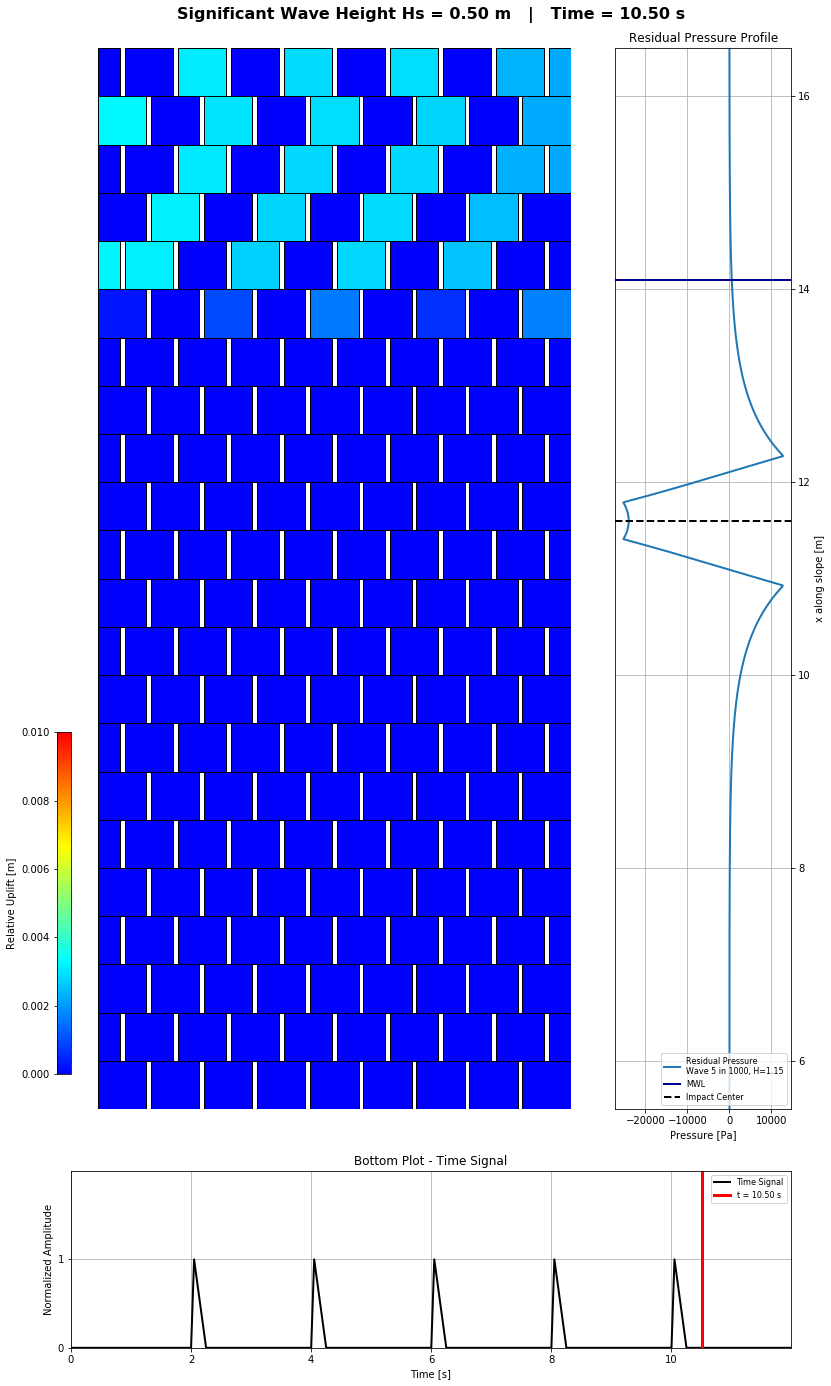

✅ Finished plotting block grid with uplift and residual pressure.


In [10]:
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from scipy.linalg import solve
from mpl_toolkits.axes_grid1 import make_axes_locatable

target_time = 10.5    # time in seconds to visualize

# ------------------------------
# Define brick layout parameters
# ------------------------------
full_w = 0.5
full_h = 0.5
half_w = 0.225
half_h = 0.5
horizontal_spacing = 0.05
v_spacing = 0.0

# Compute grid width for even rows (widest rows)
grid_width = (9 * full_w) + (8 * horizontal_spacing)
print(f"Grid width: {grid_width:.3f} m")

rows = 22

# ------------------------------
# Load uplift data
# ------------------------------

csv_path = 'relative_uplift_timeseries_06_DS60_2_corrected.csv'

df_uplift = pd.read_csv(csv_path)

# Detect time column automatically
if df_uplift.columns[0].lower() == "step":
    time_col = "CumulativeTime" if "CumulativeTime" in df_uplift.columns else df_uplift.columns[1]
else:
    time_col = df_uplift.columns[0]

# Round times for matching
df_uplift[time_col] = df_uplift[time_col].round(2)
row_df = df_uplift[df_uplift[time_col] == round(target_time, 2)]

if row_df.empty:
    raise ValueError(f"⛔ Time step {target_time:.2f} not found in CSV.")

# ✅ SAFELY extract only block columns (those starting with "B-")
block_cols = [c for c in row_df.columns if c.startswith("B-")]
block_data = row_df[block_cols].iloc[0]

# ✅ Fixed color normalization from 0 to block depth (0.15 m)
norm = plt.Normalize(vmin=0, vmax=0.01)

# Custom colormap: blue → red
colors = ["#0000FF", "#00FFFF", "#FFFF00", "#FF0000"]
cmap = LinearSegmentedColormap.from_list("uplift_cmap", colors, N=256)

no_data_color = "lightgray"

# ------------------------------
# Create time signal for bottom plot
# ------------------------------

pulse_t = np.array([0.0, 0.05, 0.25])
pulse_val = np.array([0.0, 1.0, 0.0])

total_waves = 5
pulse_duration = 0.25
pulse_interval = 2.0
gravity_time = 2.0
dt = 0.01

end_time = gravity_time + total_waves * pulse_interval
time_signal = np.arange(0, end_time, dt)

signal = np.zeros_like(time_signal)

for wave in range(total_waves):
    t_start = gravity_time + wave * pulse_interval
    active = (time_signal >= t_start) & (time_signal <= t_start + pulse_duration)
    local_time = time_signal[active] - t_start
    pulse = np.interp(local_time, pulse_t, pulse_val)
    signal[active] = pulse

df_signal = pd.DataFrame({
    "Time": time_signal,
    "Signal": signal
})

# ------------------------------
# Simulate residual profiles
# ------------------------------

Hs = 0.5
rho_w = 1025.0
g = 9.81
Tp = 5.59
tan_beta = 1.0 / 3.0
D = 0.30
b = 0.30
k = 0.19
k_prime = 0.05
Lambda = np.sqrt(D * b * k / k_prime)
SWL = 4.7
dx = 0.01
x = np.arange(0, 20.0 + dx, dx)
N = len(x)

x_mwl = SWL / tan_beta
print(f"MWL (along slope): {x_mwl:.2f} m")

block_length = 0.5
slope = tan_beta
block_dx = block_length * np.cos(np.arctan(slope))
block_start = 6.0
block_positions = [block_start + i * block_dx for i in range(22)]

sigma = Hs / np.sqrt(2)
exceed_probs = np.arange(1, 6, 1) / 1000.0
wave_heights = sigma * np.sqrt(-2 * np.log(exceed_probs))

wave_pressures = {}
residual_profiles = {}
impact_centers = {}

for i, H_wave in enumerate(wave_heights):
    Tm_1_0 = Tp / 1.1
    L_m_1_0 = (g * Tm_1_0 ** 2) / (2.0 * np.pi)
    xi = tan_beta / np.sqrt(H_wave / L_m_1_0)
    z_SWL = H_wave * (0.8 + 0.6 * np.tanh(xi - 2.1)) if xi < 3 else np.nan
    x_center = (SWL - z_SWL) / tan_beta

    w_base = (7 / 6) * H_wave
    w_top = (1 / 3) * H_wave
    x_left_base = x_center - w_base / 2
    x_right_base = x_center + w_base / 2
    x_left_top = x_center - w_top / 2
    x_right_top = x_center + w_top / 2

    denom = (xi - 0.2) ** 2
    P_dimless = 8.0 - 1.6 * xi - 2.0 / denom
    P_max = P_dimless * rho_w * g * H_wave

    p_vals = np.zeros_like(x)
    for j, xx in enumerate(x):
        if x_left_base <= xx < x_left_top:
            p_vals[j] = P_max * (xx - x_left_base) / (x_left_top - x_left_base)
        elif x_left_top <= xx <= x_right_top:
            p_vals[j] = P_max
        elif x_right_top < xx <= x_right_base:
            p_vals[j] = P_max * (x_right_base - xx) / (x_right_base - x_right_top)

    b_vec = -p_vals.copy()
    b_vec[0] = b_vec[-1] = 0
    A = np.zeros((N, N))
    coeff = Lambda ** 2 / dx ** 2
    for j in range(1, N - 1):
        A[j, j - 1] = coeff
        A[j, j] = -2 * coeff - 1
        A[j, j + 1] = coeff
    A[0, 0] = A[-1, -1] = 1.0
    phi_F = solve(A, b_vec)
    residual = phi_F - p_vals

    wave_name = f"Wave {i+1} in 1000, H={H_wave:.2f}"
    residual_profiles[wave_name] = residual
    wave_pressures[wave_name] = p_vals
    impact_centers[wave_name] = x_center

wave_to_plot = list(residual_profiles.keys())[0]

active_wave = None
for wave_idx in range(total_waves):
    t_start = gravity_time + wave_idx * pulse_interval
    t_end = gravity_time + (wave_idx + 1) * pulse_interval
    if t_start <= target_time < t_end:
        active_wave = wave_idx
        break

if active_wave is not None:
    wave_name = list(residual_profiles.keys())[active_wave]
    print(f"✅ Time {target_time:.2f} s belongs to {wave_name}")
else:
    print(f"ℹ️ Time {target_time:.2f} s is during gravity loading or after waves.")

fig = plt.figure(figsize=(10, 19))

gs = gridspec.GridSpec(
    nrows=2,
    ncols=2,
    width_ratios=[3, 1],
    height_ratios=[6, 1],
    wspace=0.05,
    hspace=0.1
)

ax_grid = fig.add_subplot(gs[0, 0])

for row_num in range(1, rows + 1):
    current_y = (rows - row_num) * (full_h + v_spacing)
    is_half = (row_num % 2 == 1)
    if is_half:
        block_sequence = (
            [(half_w, f"B-{row_num}-1")] +
            [(full_w, f"B-{row_num}-{col}") for col in range(2, 10)] +
            [(half_w, f"B-{row_num}-10")]
        )
    else:
        block_sequence = [
            (full_w, f"B-{row_num}-{col}") for col in range(1, 10)
        ]

    x_pos = 0.0
    for block_w, block_name in block_sequence:
        if block_name in block_data:
            value = block_data[block_name]
            if np.isnan(value):
                color = no_data_color
            else:
                color = cmap(norm(value))
        else:
            color = no_data_color

        rect = patches.Rectangle(
            (x_pos, current_y),
            block_w, full_h,
            edgecolor='black',
            facecolor=color,
            linewidth=1
        )
        ax_grid.add_patch(rect)
        x_pos += block_w + horizontal_spacing

ax_grid.set_aspect('equal')
ax_grid.set_xlim(0, grid_width)
ax_grid.set_ylim(0, rows * full_h)
ax_grid.axis('off')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cax = fig.add_axes([-0.02, 0.2, 0.02, 0.25])
cbar = plt.colorbar(sm, cax=cax, orientation='vertical')
cbar.set_label('Relative Uplift [m]')
cbar.ax.yaxis.set_label_position('left')
cbar.ax.yaxis.set_ticks_position('left')

ax_side = fig.add_subplot(gs[0, 1])
if active_wave is not None:
    wave_name = list(residual_profiles.keys())[active_wave]
    residual_vals = residual_profiles[wave_name]
    x_center = impact_centers[wave_name]
else:
    wave_name = wave_to_plot
    residual_vals = residual_profiles[wave_name]
    x_center = impact_centers[wave_name]

ax_side.plot(
    residual_vals,
    x,
    color='#1f77b4',
    linewidth=2,
    label=f"Residual Pressure\n{wave_name}"
)
ax_side.axhline(
    x_mwl,
    color='darkblue',
    linestyle='-',
    linewidth=2,
    label='MWL'
)
ax_side.axhline(
    x_center,
    color='black',
    linestyle='--',
    linewidth=2,
    label='Impact Center'
)
ax_side.invert_yaxis()
ax_side.set_xlabel('Pressure [Pa]')
ax_side.set_ylabel('x along slope [m]')
ax_side.set_ylim(5.5, 16.5)
ax_side.yaxis.tick_right()
ax_side.yaxis.set_label_position("right")
ax_side.set_title("Residual Pressure Profile")
ax_side.grid(True)
ax_side.legend(loc='lower right', fontsize=8)

ax_bottom = fig.add_subplot(gs[1, :])
ax_bottom.plot(
    df_signal["Time"],
    df_signal["Signal"],
    color='black',
    linewidth=2,
    label='Time Signal'
)
ax_bottom.axvline(
    target_time,
    color='red',
    linestyle='-',
    linewidth=3,
    label=f"t = {target_time:.2f} s"
)
ax_bottom.set_xlim(0, df_signal["Time"].iloc[-1])
ax_bottom.set_xlabel('Time [s]')
ax_bottom.set_ylabel('Normalized Amplitude')
ax_bottom.set_yticks([0, 1])
ax_bottom.set_ylim(0, 2)
ax_bottom.grid(True)
ax_bottom.set_title('Bottom Plot - Time Signal')
ax_bottom.legend(loc='upper right', fontsize=8)

fig.suptitle(
    f"Significant Wave Height Hs = {Hs:.2f} m   |   Time = {target_time:.2f} s",
    fontsize=16,
    fontweight="bold"
)
plt.subplots_adjust(left=0, right=1, top=0.95, bottom=0, wspace=0, hspace=0)
plt.show()

print("✅ Finished plotting block grid with uplift and residual pressure.")


Grid width: 4.900 m
MWL (along slope): 14.10 m
✅ Time 11.00 s belongs to Wave 5 in 1000, H=1.15


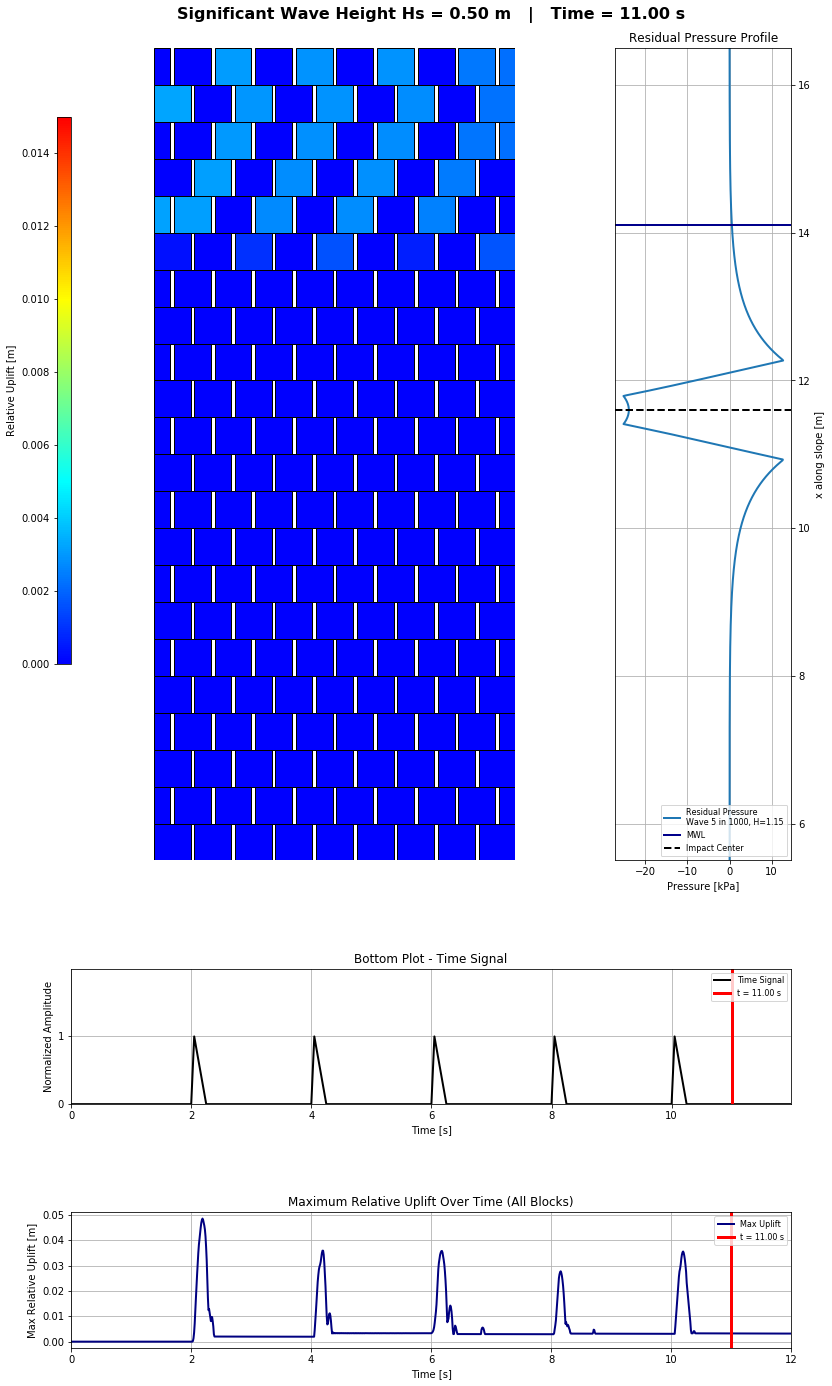

✅ Finished plotting block grid with uplift and residual pressure.


In [11]:
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from scipy.linalg import solve
from mpl_toolkits.axes_grid1 import make_axes_locatable

# --- Settings ---
fly_out_value = 0.151
target_time = 11   # time in seconds to visualize
csv_path = 'relative_uplift_timeseries_06_DS60_2_corrected.csv'
df_uplift = pd.read_csv(csv_path)

# ------------------------------
# Define brick layout parameters
# ------------------------------
full_w = 0.5
full_h = 0.5
half_w = 0.225
half_h = 0.5
horizontal_spacing = 0.05
v_spacing = 0.0

grid_width = (9 * full_w) + (8 * horizontal_spacing)
print(f"Grid width: {grid_width:.3f} m")

rows = 22

# ------------------------------
# Load uplift data
# ------------------------------



# Detect time column automatically
if df_uplift.columns[0].lower() == "step":
    time_col = "CumulativeTime" if "CumulativeTime" in df_uplift.columns else df_uplift.columns[1]
else:
    time_col = df_uplift.columns[0]

# Round times for matching
df_uplift[time_col] = df_uplift[time_col].round(2)

# Extract data for plotting the block grid
row_df = df_uplift[df_uplift[time_col] == round(target_time, 2)]
if row_df.empty:
    raise ValueError(f"⛔ Time step {target_time:.2f} not found in CSV.")

block_cols = [c for c in df_uplift.columns if c.startswith("B-")]
block_data = row_df[block_cols].iloc[0]

# Normalize color for uplift values
norm = plt.Normalize(vmin=0, vmax=0.015)

# Custom colormap
colors = ["#0000FF", "#00FFFF", "#FFFF00", "#FF0000"]
cmap = LinearSegmentedColormap.from_list("uplift_cmap", colors, N=256)
no_data_color = "lightgray"

# ------------------------------
# Create time signal
# ------------------------------

pulse_t = np.array([0.0, 0.05, 0.25])
pulse_val = np.array([0.0, 1.0, 0.0])

total_waves = 5
pulse_duration = 0.25
pulse_interval = 2.0
gravity_time = 2.0
dt = 0.01

end_time = gravity_time + total_waves * pulse_interval
time_signal = np.arange(0, end_time, dt)

signal = np.zeros_like(time_signal)
for wave in range(total_waves):
    t_start = gravity_time + wave * pulse_interval
    active = (time_signal >= t_start) & (time_signal <= t_start + pulse_duration)
    local_time = time_signal[active] - t_start
    pulse = np.interp(local_time, pulse_t, pulse_val)
    signal[active] = pulse

df_signal = pd.DataFrame({
    "Time": time_signal,
    "Signal": signal
})

# ------------------------------
# Simulate residual profiles
# ------------------------------

Hs = 0.5
rho_w = 1025.0
g = 9.81
Tp = 5.59
tan_beta = 1.0 / 3.0
D = 0.30
b = 0.30
k = 0.19
k_prime = 0.05
Lambda = np.sqrt(D * b * k / k_prime)
SWL = 4.7
dx = 0.01
x = np.arange(0, 20.0 + dx, dx)
N = len(x)

x_mwl = SWL / tan_beta
print(f"MWL (along slope): {x_mwl:.2f} m")

block_length = 0.5
slope = tan_beta
block_dx = block_length * np.cos(np.arctan(slope))
block_start = 6.0
block_positions = [block_start + i * block_dx for i in range(22)]

sigma = Hs / np.sqrt(2)
exceed_probs = np.arange(1, 6, 1) / 1000.0
wave_heights = sigma * np.sqrt(-2 * np.log(exceed_probs))

wave_pressures = {}
residual_profiles = {}
impact_centers = {}

for i, H_wave in enumerate(wave_heights):
    Tm_1_0 = Tp / 1.1
    L_m_1_0 = (g * Tm_1_0 ** 2) / (2.0 * np.pi)
    xi = tan_beta / np.sqrt(H_wave / L_m_1_0)
    z_SWL = H_wave * (0.8 + 0.6 * np.tanh(xi - 2.1)) if xi < 3 else np.nan
    x_center = (SWL - z_SWL) / tan_beta

    w_base = (7 / 6) * H_wave
    w_top = (1 / 3) * H_wave
    x_left_base = x_center - w_base / 2
    x_right_base = x_center + w_base / 2
    x_left_top = x_center - w_top / 2
    x_right_top = x_center + w_top / 2

    denom = (xi - 0.2) ** 2
    P_dimless = 8.0 - 1.6 * xi - 2.0 / denom
    P_max = P_dimless * rho_w * g * H_wave

    p_vals = np.zeros_like(x)
    for j, xx in enumerate(x):
        if x_left_base <= xx < x_left_top:
            p_vals[j] = P_max * (xx - x_left_base) / (x_left_top - x_left_base)
        elif x_left_top <= xx <= x_right_top:
            p_vals[j] = P_max
        elif x_right_top < xx <= x_right_base:
            p_vals[j] = P_max * (x_right_base - xx) / (x_right_base - x_right_top)

    b_vec = -p_vals.copy()
    b_vec[0] = b_vec[-1] = 0
    A = np.zeros((N, N))
    coeff = Lambda ** 2 / dx ** 2
    for j in range(1, N - 1):
        A[j, j - 1] = coeff
        A[j, j] = -2 * coeff - 1
        A[j, j + 1] = coeff
    A[0, 0] = A[-1, -1] = 1.0
    phi_F = solve(A, b_vec)
    residual = phi_F - p_vals

    wave_name = f"Wave {i+1} in 1000, H={H_wave:.2f}"
    residual_profiles[wave_name] = residual
    wave_pressures[wave_name] = p_vals
    impact_centers[wave_name] = x_center

wave_to_plot = list(residual_profiles.keys())[0]

active_wave = None
for wave_idx in range(total_waves):
    t_start = gravity_time + wave_idx * pulse_interval
    t_end = gravity_time + (wave_idx + 1) * pulse_interval
    if t_start <= target_time < t_end:
        active_wave = wave_idx
        break

if active_wave is not None:
    wave_name = list(residual_profiles.keys())[active_wave]
    print(f"✅ Time {target_time:.2f} s belongs to {wave_name}")
else:
    print(f"ℹ️ Time {target_time:.2f} s is during gravity loading or after waves.")

# ------------------------------
# Plotting
# ------------------------------

fig = plt.figure(figsize=(10, 19))

gs = gridspec.GridSpec(
    nrows=3,
    ncols=2,
    width_ratios=[3, 1],
    height_ratios=[6, 1, 1],
    wspace=0.05,
    hspace=0.3
)

# --- Top left: block grid ---
ax_grid = fig.add_subplot(gs[0, 0])

for row_num in range(1, rows + 1):
    current_y = (rows - row_num) * (full_h + v_spacing)
    is_half = (row_num % 2 == 1)
    if is_half:
        block_sequence = (
            [(half_w, f"B-{row_num}-1")] +
            [(full_w, f"B-{row_num}-{col}") for col in range(2, 10)] +
            [(half_w, f"B-{row_num}-10")]
        )
    else:
        block_sequence = [
            (full_w, f"B-{row_num}-{col}") for col in range(1, 10)
        ]

    x_pos = 0.0
    for block_w, block_name in block_sequence:
        if block_name in block_data:
            value = block_data[block_name]
            if np.isnan(value):
                color = no_data_color
            else:
                color = cmap(norm(value))
        else:
            color = no_data_color

        rect = patches.Rectangle(
            (x_pos, current_y),
            block_w, full_h,
            edgecolor='black',
            facecolor=color,
            linewidth=1
        )
        ax_grid.add_patch(rect)
        x_pos += block_w + horizontal_spacing

ax_grid.set_aspect('equal')
ax_grid.set_xlim(0, grid_width)
ax_grid.set_ylim(0, rows * full_h)
ax_grid.axis('off')

# Colorbar (taller and higher)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cax = fig.add_axes([-0.02, 0.5, 0.02, 0.4])
cbar = plt.colorbar(sm, cax=cax, orientation='vertical')
cbar.set_label('Relative Uplift [m]')
cbar.ax.yaxis.set_label_position('left')
cbar.ax.yaxis.set_ticks_position('left')

# --- Top right: residual pressure profile ---
ax_side = fig.add_subplot(gs[0, 1])

if active_wave is not None:
    wave_name = list(residual_profiles.keys())[active_wave]
    residual_vals = residual_profiles[wave_name]
    x_center = impact_centers[wave_name]
else:
    wave_name = wave_to_plot
    residual_vals = residual_profiles[wave_name]
    x_center = impact_centers[wave_name]

residual_vals_kPa = residual_vals / 1000.0

ax_side.plot(
    residual_vals_kPa,
    x,
    color='#1f77b4',
    linewidth=2,
    label=f"Residual Pressure\n{wave_name}"
)
ax_side.axhline(
    x_mwl,
    color='darkblue',
    linestyle='-',
    linewidth=2,
    label='MWL'
)
ax_side.axhline(
    x_center,
    color='black',
    linestyle='--',
    linewidth=2,
    label='Impact Center'
)
ax_side.invert_yaxis()
ax_side.set_xlabel('Pressure [kPa]')
ax_side.set_ylabel('x along slope [m]')
ax_side.set_ylim(5.5, 16.5)
ax_side.yaxis.tick_right()
ax_side.yaxis.set_label_position("right")
ax_side.set_title("Residual Pressure Profile")
ax_side.grid(True)
ax_side.legend(loc='lower right', fontsize=8)

# --- Middle: time signal ---
ax_bottom = fig.add_subplot(gs[1, :])
ax_bottom.plot(
    df_signal["Time"],
    df_signal["Signal"],
    color='black',
    linewidth=2,
    label='Time Signal'
)
ax_bottom.axvline(
    target_time,
    color='red',
    linestyle='-',
    linewidth=3,
    label=f"t = {target_time:.2f} s"
)
ax_bottom.set_xlim(0, df_signal["Time"].iloc[-1])
ax_bottom.set_xlabel('Time [s]')
ax_bottom.set_ylabel('Normalized Amplitude')
ax_bottom.set_yticks([0, 1])
ax_bottom.set_ylim(0, 2)
ax_bottom.grid(True)
ax_bottom.set_title('Bottom Plot - Time Signal')
ax_bottom.legend(loc='upper right', fontsize=8)

# --- Bottom: max uplift over time ---
ax_uplift = fig.add_subplot(gs[2, :])

block_data_all = df_uplift[block_cols].copy()

fly_out_mask = (block_data_all == fly_out_value)
block_data_cleaned = block_data_all.replace(fly_out_value, np.nan)

max_uplift = block_data_cleaned.max(axis=1)

first_loss_times = []
for col in block_cols:
    fly_out_indices = fly_out_mask.index[fly_out_mask[col]].tolist()
    if fly_out_indices:
        first_idx = fly_out_indices[0]
        first_loss_times.append(df_uplift.loc[first_idx, time_col])

first_loss_times = sorted(set(first_loss_times))

ax_uplift.plot(
    df_uplift[time_col],
    max_uplift,
    color='navy',
    linewidth=2,
    label='Max Uplift'
)
ax_uplift.axvline(
    target_time,
    color='red',
    linestyle='-',
    linewidth=3,
    label=f"t = {target_time:.2f} s"
)

if len(first_loss_times) > 0:
    cross_y_value = max_uplift.max() * 1.1 if max_uplift.max() > 0 else 0.01
    ax_uplift.scatter(
        first_loss_times,
        [cross_y_value] * len(first_loss_times),
        color='red',
        marker='x',
        s=80,
        label='Block Loss (First Occurrence)'
    )

ax_uplift.set_xlabel("Time [s]")
ax_uplift.set_xlim(0, 12)
ax_uplift.set_ylabel("Max Relative Uplift [m]")
ax_uplift.set_title("Maximum Relative Uplift Over Time (All Blocks)")
ax_uplift.legend(loc='upper right', fontsize=8)
ax_uplift.grid(True)

# --- Global title ---
fig.suptitle(
    f"Significant Wave Height Hs = {Hs:.2f} m   |   Time = {target_time:.2f} s",
    fontsize=16,
    fontweight="bold"
)

plt.subplots_adjust(left=0, right=1, top=0.95, bottom=0, wspace=0, hspace=0)
plt.show()

fig.savefig(csv_path.replace(".csv", ".png"), dpi=300, bbox_inches='tight')
print("✅ Finished plotting block grid with uplift and residual pressure.")


Grid width: 4.900 m
MWL (along slope): 14.10 m
✅ Time 11.00 s belongs to Wave 5 in 1000, H=1.15


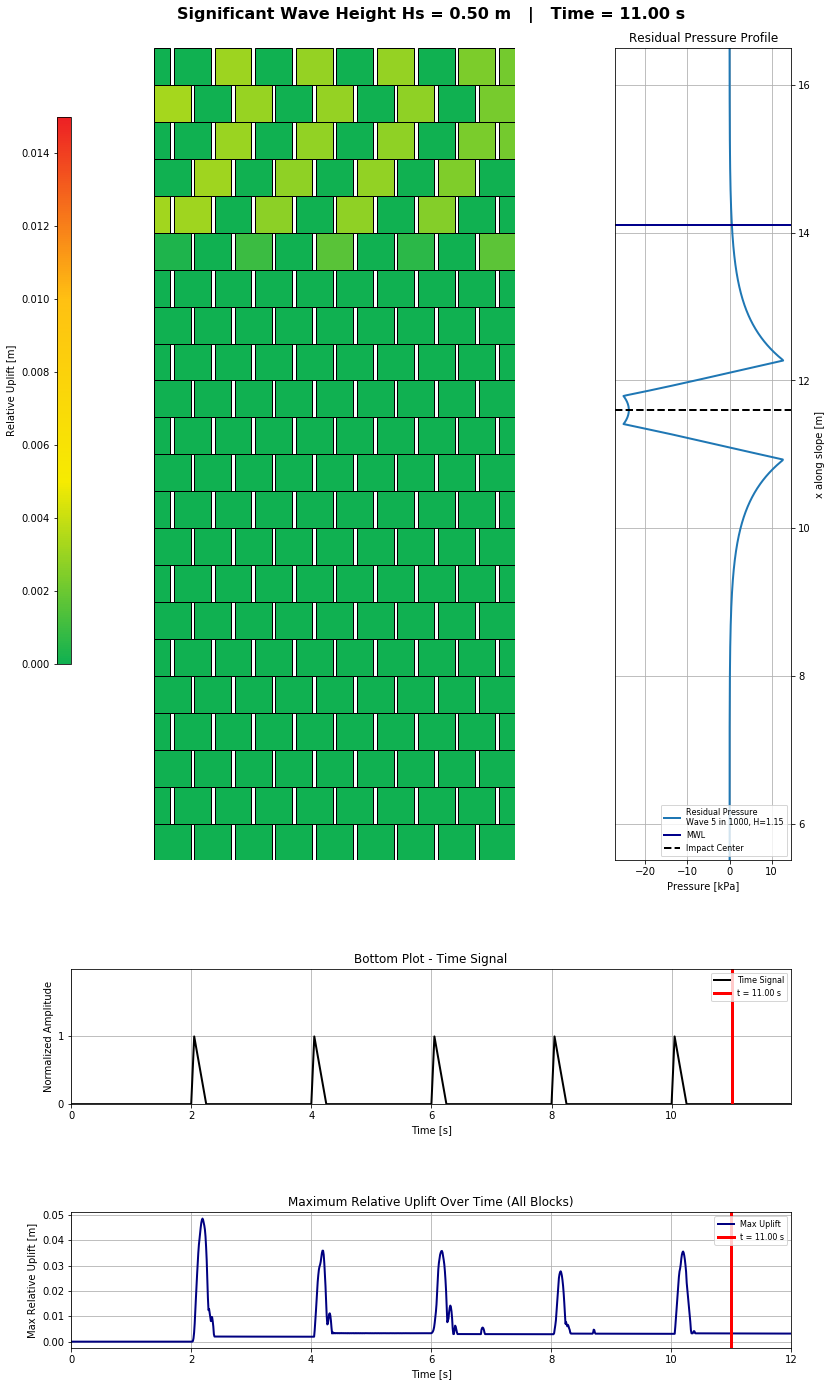

✅ Finished plotting block grid with uplift and residual pressure.


In [13]:
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from scipy.linalg import solve
from mpl_toolkits.axes_grid1 import make_axes_locatable

# --- Settings ---
fly_out_value = 0.151
target_time = 11   # time in seconds to visualize
csv_path = 'relative_uplift_timeseries_06_DS60_2_corrected.csv'
df_uplift = pd.read_csv(csv_path)

# ------------------------------
# Define brick layout parameters
# ------------------------------
full_w = 0.5
full_h = 0.5
half_w = 0.225
half_h = 0.5
horizontal_spacing = 0.05
v_spacing = 0.0

grid_width = (9 * full_w) + (8 * horizontal_spacing)
print(f"Grid width: {grid_width:.3f} m")

rows = 22

# ------------------------------
# Load uplift data
# ------------------------------



# Detect time column automatically
if df_uplift.columns[0].lower() == "step":
    time_col = "CumulativeTime" if "CumulativeTime" in df_uplift.columns else df_uplift.columns[1]
else:
    time_col = df_uplift.columns[0]

# Round times for matching
df_uplift[time_col] = df_uplift[time_col].round(2)

# Extract data for plotting the block grid
row_df = df_uplift[df_uplift[time_col] == round(target_time, 2)]
if row_df.empty:
    raise ValueError(f"⛔ Time step {target_time:.2f} not found in CSV.")

block_cols = [c for c in df_uplift.columns if c.startswith("B-")]
block_data = row_df[block_cols].iloc[0]

# Normalize color for uplift values
norm = plt.Normalize(vmin=0, vmax=0.015)

# Custom colormap
# colors = ["#0000FF", "#00FFFF", "#FFFF00", "#FF0000"]
colors = ["#10b151", "#f6eb01", "#ffc112", "#ed2024"]
cmap = LinearSegmentedColormap.from_list("uplift_cmap", colors, N=256)
no_data_color = "lightgray"

# ------------------------------
# Create time signal
# ------------------------------

pulse_t = np.array([0.0, 0.05, 0.25])
pulse_val = np.array([0.0, 1.0, 0.0])

total_waves = 5
pulse_duration = 0.25
pulse_interval = 2.0
gravity_time = 2.0
dt = 0.01

end_time = gravity_time + total_waves * pulse_interval
time_signal = np.arange(0, end_time, dt)

signal = np.zeros_like(time_signal)
for wave in range(total_waves):
    t_start = gravity_time + wave * pulse_interval
    active = (time_signal >= t_start) & (time_signal <= t_start + pulse_duration)
    local_time = time_signal[active] - t_start
    pulse = np.interp(local_time, pulse_t, pulse_val)
    signal[active] = pulse

df_signal = pd.DataFrame({
    "Time": time_signal,
    "Signal": signal
})

# ------------------------------
# Simulate residual profiles
# ------------------------------

Hs = 0.5
rho_w = 1025.0
g = 9.81
Tp = 5.59
tan_beta = 1.0 / 3.0
D = 0.30
b = 0.30
k = 0.19
k_prime = 0.05
Lambda = np.sqrt(D * b * k / k_prime)
SWL = 4.7
dx = 0.01
x = np.arange(0, 20.0 + dx, dx)
N = len(x)

x_mwl = SWL / tan_beta
print(f"MWL (along slope): {x_mwl:.2f} m")

block_length = 0.5
slope = tan_beta
block_dx = block_length * np.cos(np.arctan(slope))
block_start = 6.0
block_positions = [block_start + i * block_dx for i in range(22)]

sigma = Hs / np.sqrt(2)
exceed_probs = np.arange(1, 6, 1) / 1000.0
wave_heights = sigma * np.sqrt(-2 * np.log(exceed_probs))

wave_pressures = {}
residual_profiles = {}
impact_centers = {}

for i, H_wave in enumerate(wave_heights):
    Tm_1_0 = Tp / 1.1
    L_m_1_0 = (g * Tm_1_0 ** 2) / (2.0 * np.pi)
    xi = tan_beta / np.sqrt(H_wave / L_m_1_0)
    z_SWL = H_wave * (0.8 + 0.6 * np.tanh(xi - 2.1)) if xi < 3 else np.nan
    x_center = (SWL - z_SWL) / tan_beta

    w_base = (7 / 6) * H_wave
    w_top = (1 / 3) * H_wave
    x_left_base = x_center - w_base / 2
    x_right_base = x_center + w_base / 2
    x_left_top = x_center - w_top / 2
    x_right_top = x_center + w_top / 2

    denom = (xi - 0.2) ** 2
    P_dimless = 8.0 - 1.6 * xi - 2.0 / denom
    P_max = P_dimless * rho_w * g * H_wave

    p_vals = np.zeros_like(x)
    for j, xx in enumerate(x):
        if x_left_base <= xx < x_left_top:
            p_vals[j] = P_max * (xx - x_left_base) / (x_left_top - x_left_base)
        elif x_left_top <= xx <= x_right_top:
            p_vals[j] = P_max
        elif x_right_top < xx <= x_right_base:
            p_vals[j] = P_max * (x_right_base - xx) / (x_right_base - x_right_top)

    b_vec = -p_vals.copy()
    b_vec[0] = b_vec[-1] = 0
    A = np.zeros((N, N))
    coeff = Lambda ** 2 / dx ** 2
    for j in range(1, N - 1):
        A[j, j - 1] = coeff
        A[j, j] = -2 * coeff - 1
        A[j, j + 1] = coeff
    A[0, 0] = A[-1, -1] = 1.0
    phi_F = solve(A, b_vec)
    residual = phi_F - p_vals

    wave_name = f"Wave {i+1} in 1000, H={H_wave:.2f}"
    residual_profiles[wave_name] = residual
    wave_pressures[wave_name] = p_vals
    impact_centers[wave_name] = x_center

wave_to_plot = list(residual_profiles.keys())[0]

active_wave = None
for wave_idx in range(total_waves):
    t_start = gravity_time + wave_idx * pulse_interval
    t_end = gravity_time + (wave_idx + 1) * pulse_interval
    if t_start <= target_time < t_end:
        active_wave = wave_idx
        break

if active_wave is not None:
    wave_name = list(residual_profiles.keys())[active_wave]
    print(f"✅ Time {target_time:.2f} s belongs to {wave_name}")
else:
    print(f"ℹ️ Time {target_time:.2f} s is during gravity loading or after waves.")

# ------------------------------
# Plotting
# ------------------------------

fig = plt.figure(figsize=(10, 19))

gs = gridspec.GridSpec(
    nrows=3,
    ncols=2,
    width_ratios=[3, 1],
    height_ratios=[6, 1, 1],
    wspace=0.05,
    hspace=0.3
)

# --- Top left: block grid ---
ax_grid = fig.add_subplot(gs[0, 0])

for row_num in range(1, rows + 1):
    current_y = (rows - row_num) * (full_h + v_spacing)
    is_half = (row_num % 2 == 1)
    if is_half:
        block_sequence = (
            [(half_w, f"B-{row_num}-1")] +
            [(full_w, f"B-{row_num}-{col}") for col in range(2, 10)] +
            [(half_w, f"B-{row_num}-10")]
        )
    else:
        block_sequence = [
            (full_w, f"B-{row_num}-{col}") for col in range(1, 10)
        ]

    x_pos = 0.0
    for block_w, block_name in block_sequence:
        if block_name in block_data:
            value = block_data[block_name]
            if np.isnan(value):
                color = no_data_color
            else:
                color = cmap(norm(value))
        else:
            color = no_data_color

        rect = patches.Rectangle(
            (x_pos, current_y),
            block_w, full_h,
            edgecolor='black',
            facecolor=color,
            linewidth=1
        )
        ax_grid.add_patch(rect)
        x_pos += block_w + horizontal_spacing

ax_grid.set_aspect('equal')
ax_grid.set_xlim(0, grid_width)
ax_grid.set_ylim(0, rows * full_h)
ax_grid.axis('off')

# Colorbar (taller and higher)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cax = fig.add_axes([-0.02, 0.5, 0.02, 0.4])
cbar = plt.colorbar(sm, cax=cax, orientation='vertical')
cbar.set_label('Relative Uplift [m]')
cbar.ax.yaxis.set_label_position('left')
cbar.ax.yaxis.set_ticks_position('left')

# --- Top right: residual pressure profile ---
ax_side = fig.add_subplot(gs[0, 1])

if active_wave is not None:
    wave_name = list(residual_profiles.keys())[active_wave]
    residual_vals = residual_profiles[wave_name]
    x_center = impact_centers[wave_name]
else:
    wave_name = wave_to_plot
    residual_vals = residual_profiles[wave_name]
    x_center = impact_centers[wave_name]

residual_vals_kPa = residual_vals / 1000.0

ax_side.plot(
    residual_vals_kPa,
    x,
    color='#1f77b4',
    linewidth=2,
    label=f"Residual Pressure\n{wave_name}"
)
ax_side.axhline(
    x_mwl,
    color='darkblue',
    linestyle='-',
    linewidth=2,
    label='MWL'
)
ax_side.axhline(
    x_center,
    color='black',
    linestyle='--',
    linewidth=2,
    label='Impact Center'
)
ax_side.invert_yaxis()
ax_side.set_xlabel('Pressure [kPa]')
ax_side.set_ylabel('x along slope [m]')
ax_side.set_ylim(5.5, 16.5)
ax_side.yaxis.tick_right()
ax_side.yaxis.set_label_position("right")
ax_side.set_title("Residual Pressure Profile")
ax_side.grid(True)
ax_side.legend(loc='lower right', fontsize=8)

# --- Middle: time signal ---
ax_bottom = fig.add_subplot(gs[1, :])
ax_bottom.plot(
    df_signal["Time"],
    df_signal["Signal"],
    color='black',
    linewidth=2,
    label='Time Signal'
)
ax_bottom.axvline(
    target_time,
    color='red',
    linestyle='-',
    linewidth=3,
    label=f"t = {target_time:.2f} s"
)
ax_bottom.set_xlim(0, df_signal["Time"].iloc[-1])
ax_bottom.set_xlabel('Time [s]')
ax_bottom.set_ylabel('Normalized Amplitude')
ax_bottom.set_yticks([0, 1])
ax_bottom.set_ylim(0, 2)
ax_bottom.grid(True)
ax_bottom.set_title('Bottom Plot - Time Signal')
ax_bottom.legend(loc='upper right', fontsize=8)

# --- Bottom: max uplift over time ---
ax_uplift = fig.add_subplot(gs[2, :])

block_data_all = df_uplift[block_cols].copy()

fly_out_mask = (block_data_all == fly_out_value)
block_data_cleaned = block_data_all.replace(fly_out_value, np.nan)

max_uplift = block_data_cleaned.max(axis=1)

first_loss_times = []
for col in block_cols:
    fly_out_indices = fly_out_mask.index[fly_out_mask[col]].tolist()
    if fly_out_indices:
        first_idx = fly_out_indices[0]
        first_loss_times.append(df_uplift.loc[first_idx, time_col])

first_loss_times = sorted(set(first_loss_times))

ax_uplift.plot(
    df_uplift[time_col],
    max_uplift,
    color='navy',
    linewidth=2,
    label='Max Uplift'
)
ax_uplift.axvline(
    target_time,
    color='red',
    linestyle='-',
    linewidth=3,
    label=f"t = {target_time:.2f} s"
)

if len(first_loss_times) > 0:
    cross_y_value = max_uplift.max() * 1.1 if max_uplift.max() > 0 else 0.01
    ax_uplift.scatter(
        first_loss_times,
        [cross_y_value] * len(first_loss_times),
        color='red',
        marker='x',
        s=80,
        label='Block Loss (First Occurrence)'
    )

ax_uplift.set_xlabel("Time [s]")
ax_uplift.set_xlim(0, 12)
ax_uplift.set_ylabel("Max Relative Uplift [m]")
ax_uplift.set_title("Maximum Relative Uplift Over Time (All Blocks)")
ax_uplift.legend(loc='upper right', fontsize=8)
ax_uplift.grid(True)

# --- Global title ---
fig.suptitle(
    f"Significant Wave Height Hs = {Hs:.2f} m   |   Time = {target_time:.2f} s",
    fontsize=16,
    fontweight="bold"
)

plt.subplots_adjust(left=0, right=1, top=0.95, bottom=0, wspace=0, hspace=0)
plt.show()

fig.savefig(csv_path.replace(".csv", ".png"), dpi=300, bbox_inches='tight')
print("✅ Finished plotting block grid with uplift and residual pressure.")
